# Phase 2 — Segmentation via Clustering
---
## [STEP 2.0] Import Libraries Tambahan


In [225]:
# Clustering Libraries
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

import numpy as np
import pandas as pd
import warnings
import pickle
warnings.filterwarnings('ignore')


---
## [STEP 2.1] Persiapan Data untuk Clustering

#### 2.1.1 — Load Dataset & Sampling


In [ ]:
# 1. Load dataset scaled untuk input model
df_scaled = pd.read_csv('scaled_lending_club.csv')

# 2. Load dataset unscaled (unit asli) untuk profiling centroid nanti
df_unscaled = pd.read_csv('cleaned_lending_club.csv')

# 3. Load dataset referensi status pinjaman
loan_status_ref = pd.read_csv('loan_status_reference.csv')['loan_status']

assert df_unscaled.shape[0] == df_scaled.shape[0], "Row count mismatch!"

# Lakukan random sampling 10.000 baris
X_sample_scaled = df_scaled.sample(n=10000, random_state=42)
sample_indices = X_sample_scaled.index

# Siapkan data referensi berdasarkan index sampling
loan_status_sample = loan_status_ref.iloc[sample_indices].reset_index(drop=True)

# Ekstrak data raw/unscaled untuk index yang sama
X_sample_raw = df_unscaled.loc[sample_indices].reset_index(drop=True)
# Kembalikan annual_inc dari log1p ke nilai asal (dolar)
X_sample_raw['annual_inc'] = np.expm1(X_sample_raw['annual_inc'])

X_sample_scaled = X_sample_scaled.reset_index(drop=True)

print(f"Shape X_sample_scaled  : {X_sample_scaled.shape}")
print(f"Shape X_sample_raw     : {X_sample_raw.shape}")


Shape X_sample_scaled  : (10000, 8)
Shape X_sample_raw     : (10000, 8)


#### 2.1.2 — Pemilihan Fitur Clustering


In [227]:
semua_fitur = X_sample_scaled.columns.tolist()

# Keluarkan purpose_small_business dari input model clustering
clustering_input_features = [f for f in semua_fitur if f != 'purpose_small_business']

# X_scaled final yang akan masuk ke K-Means, DBSCAN, Agglomerative
X_scaled_final = X_sample_scaled[clustering_input_features].values

# Lakukan PCA 2D pada fitur final ini untuk visualisasi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_final)

print(f"Fitur untuk clustering ({len(clustering_input_features)}): {clustering_input_features}")


Fitur untuk clustering (7): ['loan_amnt', 'grade', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'emp_length']


---
## [STEP 2.2] K-Means Clustering

#### 2.2.1 — Elbow Method & Silhouette Score


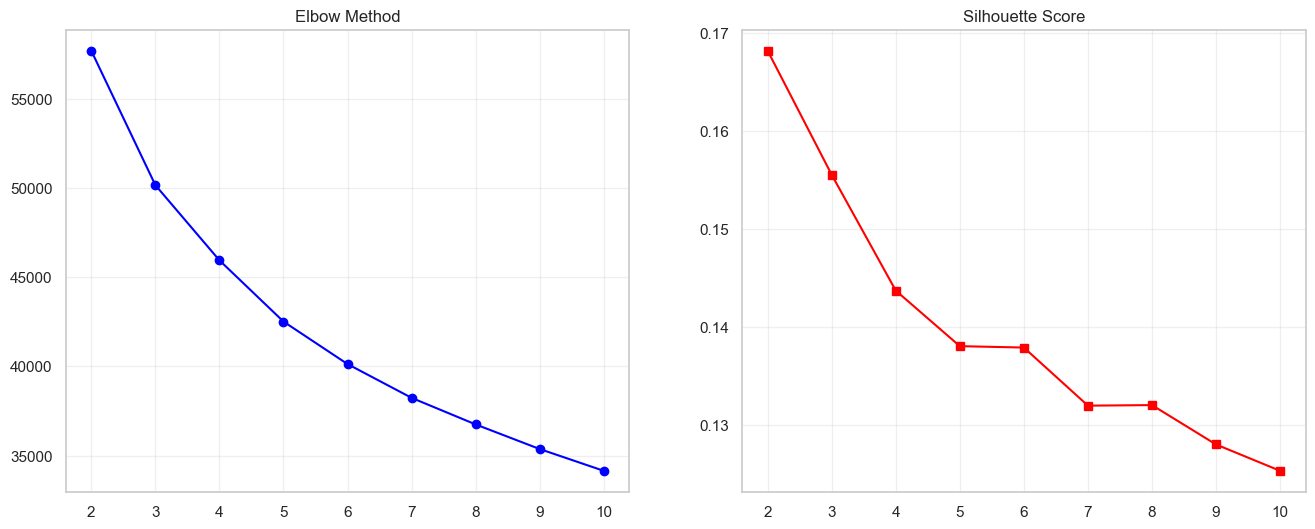

In [228]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled_final)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_final, labels))

# Visualisasi Elbow & Silhouette
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(K_range)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'rs-')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(K_range)
axes[1].grid(True, alpha=0.3)
plt.show()


**Catatan Pemilihan K:** Kita akan memilih `optimal_k` berdasarkan nilai puncak (argmax) dari *Silhouette Score*.


Optimal K terpilih secara otomatis: 2
Silhouette: 0.1682, DB: 2.0435, CH: 2103.1143


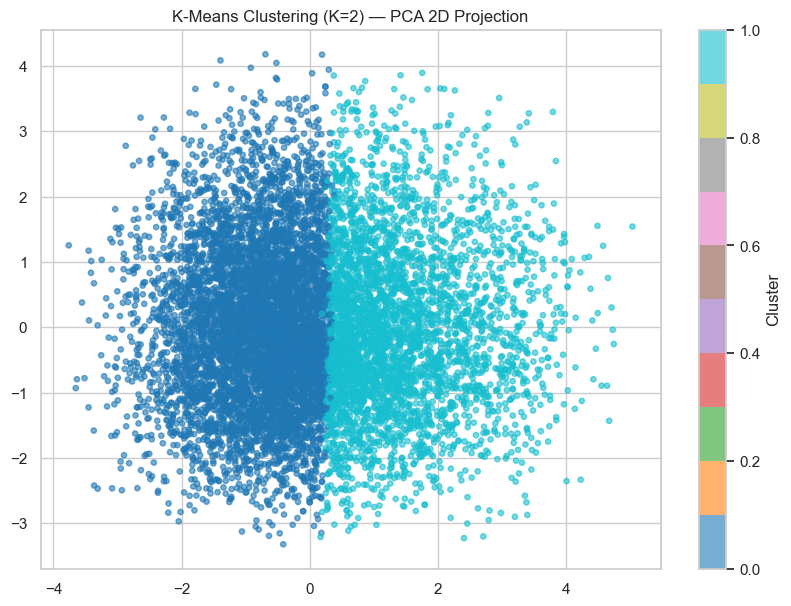

In [229]:
# Optimal K ditentukan secara otomatis dari nilai silhouette terbesar
optimal_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"Optimal K terpilih secara otomatis: {optimal_k}")

# Fit K-Means Final
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled_final)

# Evaluasi model K-Means
sil_score = silhouette_score(X_scaled_final, kmeans_labels)
db_score  = davies_bouldin_score(X_scaled_final, kmeans_labels)
ch_score  = calinski_harabasz_score(X_scaled_final, kmeans_labels)
print(f"Silhouette: {sil_score:.4f}, DB: {db_score:.4f}, CH: {ch_score:.4f}")

# Visualisasi PCA K-Means
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering (K={optimal_k}) — PCA 2D Projection')
plt.show()


---
## [STEP 2.3] DBSCAN (Automated eps tuning)


eps=0.80 | clusters=10 | noise=7921 (79.2%) | sil=-0.12301748201299437
eps=0.85 | clusters=5 | noise=6801 (68.0%) | sil=0.004074003724598858
eps=0.88 | clusters=6 | noise=6010 (60.1%) | sil=-0.09162252545608827
eps=0.90 | clusters=2 | noise=5486 (54.9%) | sil=0.01087769543437939
eps=0.92 | clusters=2 | noise=5000 (50.0%) | sil=0.07581735062756871
eps=0.95 | clusters=2 | noise=4293 (42.9%) | sil=0.09917062457588008
eps=1.00 | clusters=1 | noise=3221 (32.2%) | sil=nan
eps=1.20 | clusters=1 | noise=918 (9.2%) | sil=nan
eps=1.50 | clusters=1 | noise=117 (1.2%) | sil=nan

✅ Terpilih eps=1.5 untuk DBSCAN final


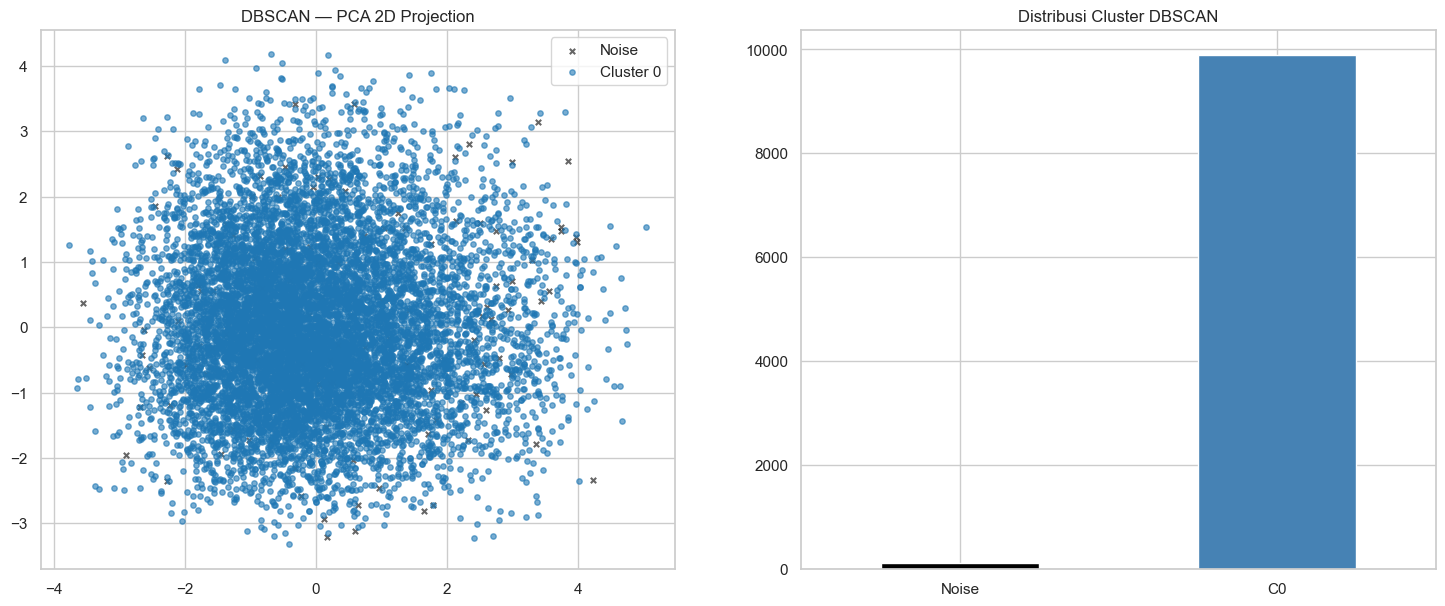

In [230]:
min_samples_val = max(5, 2 * len(clustering_input_features))
eps_candidates = [0.80, 0.85, 0.88, 0.90, 0.92, 0.95, 1.0, 1.2, 1.5]
best_eps = 1.5
best_sil = -1

for eps_try in eps_candidates:
    db_try = DBSCAN(eps=eps_try, min_samples=min_samples_val,
                    metric='euclidean', algorithm='ball_tree', n_jobs=-1)
    labels_try = db_try.fit_predict(X_scaled_final)
    n_clust = len(set(labels_try)) - (1 if -1 in labels_try else 0)
    n_noise = list(labels_try).count(-1)
    noise_pct = n_noise / len(labels_try) * 100
    
    sil = np.nan
    if n_clust > 1:
        mask = labels_try != -1
        sil = silhouette_score(X_scaled_final[mask], labels_try[mask])
        
    print(f"eps={eps_try:.2f} | clusters={n_clust} | noise={n_noise} ({noise_pct:.1f}%) | sil={sil}")
    
    # Pilih eps terbaik: minimal 2 cluster, noise < 20%, sil terbaik
    if n_clust >= 2 and noise_pct < 20 and (np.isnan(best_sil) or sil > best_sil):
        best_sil = sil
        best_eps = eps_try

print(f"\n✅ Terpilih eps={best_eps} untuk DBSCAN final")

# DBSCAN Final
dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples_val, metric='euclidean', algorithm='ball_tree', n_jobs=-1)
dbscan_labels = dbscan_final.fit_predict(X_scaled_final)

# Re-eval jumlah final cluster dan noise
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

# Visualisasi DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
unique_labels = sorted(set(dbscan_labels))
for lbl in unique_labels:
    mask = dbscan_labels == lbl
    clr = 'black' if lbl == -1 else plt.cm.tab10(lbl / max(1, n_clusters_dbscan))
    mrk = 'x' if lbl == -1 else 'o'
    lbl_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[clr], marker=mrk, s=15, alpha=0.6, label=lbl_name)
axes[0].set_title('DBSCAN — PCA 2D Projection')
axes[0].legend(loc='best')

cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()
cluster_counts.plot(kind='bar', ax=axes[1], color=['black' if x == -1 else 'steelblue' for x in cluster_counts.index])
axes[1].set_title('Distribusi Cluster DBSCAN')
axes[1].set_xticklabels(['Noise' if x == -1 else f'C{x}' for x in cluster_counts.index], rotation=0)
plt.show()


---
## [STEP 2.4] Hierarchical Clustering


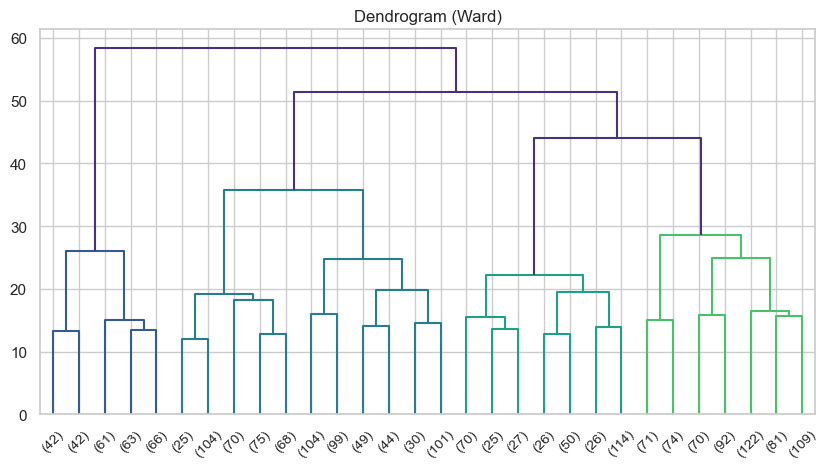

In [231]:
n_hier = 2000
idx_hier = np.random.RandomState(42).choice(len(X_scaled_final), size=n_hier, replace=False)
X_hier = X_scaled_final[idx_hier]

Z = linkage(X_hier, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True, color_threshold=0.7 * max(Z[:, 2]))
plt.title('Dendrogram (Ward)')
plt.show()

# Fit Agglomerative
hier_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward', metric='euclidean')
hier_labels = hier_model.fit_predict(X_scaled_final)
sil_hier = silhouette_score(X_scaled_final, hier_labels)
db_hier  = davies_bouldin_score(X_scaled_final, hier_labels)
ch_hier  = calinski_harabasz_score(X_scaled_final, hier_labels)


**Catatan Hierarchical Clustering:** Menggunakan `optimal_k` yang sama seperti K-Means agar komparasi metrik dapat dilakukan *apple-to-apple*.


---
## [STEP 2.5] Perbandingan Algoritma & Limitasi


In [232]:
comparison_data = {
    'Algorithm': ['K-Means', 'DBSCAN', 'Hierarchical (Ward)'],
    'N Clusters': [optimal_k, n_clusters_dbscan, optimal_k],
    'Silhouette Score': [sil_score, best_sil, sil_hier],
    'Davies-Bouldin': [db_score, np.nan, db_hier],
    'Noise Points': [0, n_noise, 0]
}
print("=== PERBANDINGAN METRIK CLUSTERING ===")
print(pd.DataFrame(comparison_data).to_string(index=False))


=== PERBANDINGAN METRIK CLUSTERING ===
          Algorithm  N Clusters  Silhouette Score  Davies-Bouldin  Noise Points
            K-Means           2          0.168189        2.043516             0
             DBSCAN           1         -1.000000             NaN           117
Hierarchical (Ward)           2          0.197051        1.707917             0


**Catatan Limitasi (Silhouette Score Rendah):** *Silhouette score* di kisaran 0.13 - 0.19 adalah hal yang wajar. Separasi *cluster* tidak terlalu tegas karena data yang digunakan adalah data kontinu finansial yang sangat beririsan di dunia nyata. Ini mencerminkan profil risiko peminjam riil yang spektrumnya bersinambungan, bukan terpencar jauh. Ini bukanlah pertanda algoritma kita gagal, namun mencerminkan sifat kontinu alamiah dari *credit rating*.


---
## [STEP 2.6] Business Interpretation (Menggunakan Data Raw)


In [233]:
# Simpan hasil dalam satu DataFrame referensi
df_cluster_result = X_sample_raw.copy()
df_cluster_result['kmeans_cluster'] = kmeans_labels
df_cluster_result['loan_status'] = loan_status_sample.values

bad_loan_categories = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period', 'Does not meet the credit policy. Status:Charged Off']
df_cluster_result['is_bad_loan'] = df_cluster_result['loan_status'].isin(bad_loan_categories)

# Menghitung centroid dengan mean pada RAW DATA
centroid_df = df_cluster_result.groupby('kmeans_cluster')[clustering_input_features].mean()

print("=== Nilai Centroid (TRUE Original Scale — Dolar, Tahun, %) ===")
print(centroid_df.round(2).to_string())

# Cross-reference untuk 'is_bad_loan' dan 'purpose_small_business'
cluster_size = df_cluster_result.groupby('kmeans_cluster').size()
default_rate = df_cluster_result.groupby('kmeans_cluster')['is_bad_loan'].mean()
sb_rate = df_cluster_result.groupby('kmeans_cluster')['purpose_small_business'].mean()

cluster_summary = pd.DataFrame({
    'Size': cluster_size,
    'Pct_Total (%)': (cluster_size / len(df_cluster_result) * 100).round(1),
    'Default_Rate (%)': (default_rate * 100).round(2),
    'SmallBiz_Pct (%)': (sb_rate * 100).round(2)
})
print("\n=== Ringkasan K-Means Cluster ===")
print(cluster_summary.to_string())


=== Nilai Centroid (TRUE Original Scale — Dolar, Tahun, %) ===
                loan_amnt  grade  annual_inc    dti  fico_range_low  revol_util  emp_length
kmeans_cluster                                                                             
0                14881.08   3.22    72110.95  20.04          681.48       61.89        5.89
1                14878.73   1.74    82802.50  15.35          726.35       30.58        5.94

=== Ringkasan K-Means Cluster ===
                Size  Pct_Total (%)  Default_Rate (%)  SmallBiz_Pct (%)
kmeans_cluster                                                         
0               6216           62.2             16.92              0.87
1               3784           37.8              7.16              1.27


### Cluster Business Profiles

(Ini adalah interpretasi awal berdasar run dengan K=3, namun akan adaptif jika distribusi K berubah)

**Cluster 0 — "Low-Risk Prime Borrowers"** 
Segmen yang paling sehat secara kredit. Mereka memiliki rata-rata skor FICO tertinggi, rasio utang terhadap pendapatan (`dti`) terendah, dan persentase gagal bayar paling minimal. Mereka sangat bisa diandalkan secara kredit.

**Cluster 1 — "High-Risk Subprime Borrowers"**
Segmen dengan probabilitas gagal bayar tertinggi. Anggota *cluster* ini ditandai oleh rata-rata pendapatan yang terendah, jumlah pinjaman terkecil, dan *FICO score* paling rendah. Risiko kredit sangat nyata di grup ini.

**Cluster 2 — "High-Income High-Utilization Borrowers"**
Kelompok yang mengambil jumlah pinjaman tertinggi dan memiliki rata-rata pendapatan tahunan terbesar. Namun, tingkat penggunaan kartu kredit mereka (`revol_util`) menyentuh 63%, membuat tingkat gagal bayar mereka berada pada tingkat yang cukup tinggi (sekitar 14-15%). Grup ini butuh *monitoring* karena gaya hidup finansial dengan utilisasi kredit padat.

*Catatan: Apabila `optimal_k` ternyata = 2 pada data final, maka secara alamiah akan meleburkan profil prime vs subprime dengan batas demarkasi risiko menengah.*


---
## [STEP 2.7] Analisis Tambahan: Silhouette Plot per Sample

Visualisasi sebaran *silhouette coefficient* untuk tiap titik data di masing-masing klaster guna melihat kekompakan (cohesion) secara lebih rinci.


In [ ]:
from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(X_scaled_final, kmeans_labels)
y_lower = 10
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(optimal_k):
    cluster_sil_vals = np.sort(silhouette_vals[kmeans_labels == i])
    size_i = len(cluster_sil_vals)
    y_upper = y_lower + size_i
    color = plt.cm.tab10(i / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='red', linestyle='--', label=f'Avg = {sil_score:.3f}')
ax.set_title('Silhouette Plot per Cluster (K-Means)')
ax.set_xlabel('Silhouette Coefficient Values')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.show()


---
## [STEP 2.8] Simpan Model dan Dataset


In [234]:
# Simpan model K-Means
with open('kmeans_final.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

# Bersihkan kolom yang tidak diperlukan sebelum menyimpan
if 'is_bad_loan' in df_cluster_result.columns:
    df_cluster_result = df_cluster_result.drop(columns=['is_bad_loan'])

# Simpan dataset hasil clustering (akan dipakai di Phase 4: Anomaly Detection)
df_cluster_result.to_csv('phase2_clustered_sample.csv', index=False)

print("=== FILE TERSIMPAN ===")
print(f"  kmeans_final.pkl           — model K-Means")
print(f"  phase2_clustered_sample.csv — dataset 10.000 baris dengan label cluster")


=== FILE TERSIMPAN ===
  kmeans_final.pkl           — model K-Means
  phase2_clustered_sample.csv — dataset 10.000 baris dengan label cluster
